# Лабораторная работа 3: Wikimedia API

Сборщик данных о предметной области через API проектов Wikimedia.

| Проект | Что берём |
|---|---|
| Википедия | статьи, тексты, гиперссылки, изображения, языковые версии |
| Викиданные | метка, описание, синонимы, свойства сущности |
| Викисловарь | толкования слов запроса |
| Wikimedia Commons | изображения по теме и картинка дня |

Тетрадь запускает тесты и сборщик, затем показывает результаты. Установка описана в `README.md`.

**Как получить сохранённый прогон:** `Run All`, дождаться конца, сохранить файл.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

LAB = Path.cwd()
if not (LAB / "main.py").exists() and (LAB / "lab3" / "main.py").exists():
    LAB = LAB / "lab3"        # ядро запустилось из корня проекта

QUERY = "Амурский тигр"
ARTICLES = 40

OUTPUT = LAB / "output" / QUERY.lower().replace(" ", "_")

def run(*command, tail=None):
    print("$", " ".join(str(part) for part in command))
    result = subprocess.run(
        [sys.executable, *[str(part) for part in command]],
        cwd=LAB, capture_output=True, text=True, encoding="utf-8", errors="replace",
    )
    lines = (result.stdout + result.stderr).splitlines()
    print("\n".join(lines[-tail:] if tail else lines))
    return result.returncode

print("Рабочая папка:", LAB)
print("Python", sys.version.split()[0])
for package in ("requests", "bs4", "lxml", "graphviz", "pytest"):
    module = __import__(package)
    print(f"{package:12} {getattr(module, '__version__', 'ok')}")

Рабочая папка: c:\projects\web-mining\lab3
Python 3.12.7
requests     2.32.5
bs4          4.14.3
lxml         5.3.0
graphviz     0.21
pytest       9.1.1


---
## Юнит-тесты

Сеть тестам не нужна: обращения к API подменяются, проверяется своя логика — фильтрация
мусорных заголовков, равномерная выборка, сборка рёбер, склейка взаимных ссылок,
поиск изолированных узлов, структура JSON.

In [2]:
run("-m", "pytest", "-q", tail=15)

$ -m pytest -q


.................................                                        [100%]
33 passed in 0.15s


0

---
## Сбор данных

Запрос подаётся на вход, дальше всё автоматически: поиск корневой статьи, выборка
связанных статей, их тексты и ссылки, Викиданные, Викисловарь, Commons и картинка дня.

In [3]:
run("main.py", QUERY, "--articles", ARTICLES)

$ main.py Амурский тигр --articles 40
Корневая статья: Амурский тигр

[ 1/40] Амурский тигр
[ 2/40] Doi
[ 3/40] Panthera tigris tigris
[ 4/40] Wayback Machine
[ 5/40] Алматинская область
[ 6/40] Амур (река)
[ 7/40] Анюй (приток Амура)
[ 8/40] Балхашский район
[ 9/40] Бастак (заповедник)
[10/40] Большая советская энциклопедия
[11/40] Буффало
[12/40] Всемирный фонд дикой природы
[13/40] Геральдика
[14/40] Герб Приморского края
[15/40] Герб Хабаровского края
[16/40] Дальневосточное отделение Российской академии наук
[17/40] Дания
[18/40] Еврейская автономная область
[19/40] Животные
[20/40] Зоология
[21/40] Изюбрь
[22/40] Институт проблем экологии и эволюции имени А. Н. Северцова РАН
[23/40] Иркутская губерния
[24/40] Китай
[25/40] Корейский кедр
[26/40] Красная книга России
[27/40] Лазовский район
[28/40] Латвийская национальная библиотека
[29/40] Лось
[30/40] Манчжурия
[31/40] Милоградовка (река)
[32/40] Национальная библиотека Чешской Республики
[33/40] Обезлесение
[34/40] Ольборг
[35/

0

### Что собралось

In [4]:
result = json.loads((OUTPUT / "result.json").read_text(encoding="utf-8"))

print("Запрос:         ", result["query"])
print("Корневая статья:", result["root"]["title"])
print("Статей:         ", len(result["articles"]))
print("Связей:         ", result["graph"]["edges"])
print("Изолированных:  ", len(result["graph"]["isolated"]))
print("Изображений:    ", len(result["commons_images"]))
print()
print(result["root"]["extract"][:400])

Запрос:          Амурский тигр
Корневая статья: Амурский тигр
Статей:          40
Связей:          144
Изолированных:   0
Изображений:     10

Аму́рский тигр, или уссури́йский тигр — популяция подвида тигра Panthera tigris tigris, населяющая Дальний Восток России и Северо-Восточный Китай, также существует информация о небольшой популяции в Северной Корее.
Аму́рский (Уссури́йский) тигр занесён в Красную книгу Российской Федерации.


### Викиданные

In [5]:
wikidata = result["wikidata"]
print(f'{wikidata["id"]}: {wikidata["label"]} — {wikidata["description"]}')
print("Синонимы:", ", ".join(wikidata["aliases"]) or "нет")
print("Языковых версий в проектах Wikimedia:", wikidata["sitelinks"])
print("Свойств сущности:", len(wikidata["properties"]))

Q69581: амурский тигр — подвид тигра, обитающий на Дальнем Востоке
Синонимы: Уссурийский тигр, Амурский (уссурийский) тигр, Сибирский тигр, Panthera tigris altaica, Северо-китайский тигр, Маньчжурский тигр, Корейский тигр
Языковых версий в проектах Wikimedia: 84
Свойств сущности: 56


### Викисловарь

In [6]:
for entry in result["wiktionary"]:
    print(entry["word"])
    print("   ", entry["definition"][:300].replace("\n", " "))

амурский
    Русский   Морфологические и синтаксические свойства  а·му́р-ский  Прилагательное, относительное, тип склонения по классификации А. Зализняка — 3a✕~. Сравнительной степени нет. Производное: Амур ➔ амур + ск + ий (суффиксальный). Корень: -амур-; суффикс: -ск; окончание: -ий.     Произношение МФА: [ɐˈm
тигр
    Русский   Морфологические и синтаксические свойства тигр Существительное, одушевлённое, мужской род, 2-е склонение (тип склонения 1a  по классификации А. А. Зализняка). Корень: -тигр-; окончание: -∅ [Тихонов, 1996].     Произношение МФА: ед. ч. [tʲiɡr]  мн. ч. [ˈtʲiɡrɨ]   Семантические свойства   Зн


### Языковые версии корневой статьи

In [7]:
for version in result["root"]["language_versions"][:10]:
    print(f'{version["lang"]:6} {version["title"]}')

ady    Амур къэплъан
af     Siberiese tier
an     Panthera tigris altaica
ar     ببر سيبيري
arz    ببر سيبيرى
avk    Jaktol (Panthera tigris altaica)
az     Amur pələngi
bar    Sibiarische Diga
bg     Сибирски тигър
bn     সাইবেরিয়ার বাঘ


### Изображения с Wikimedia Commons

In [8]:
from IPython.display import Image, display

for image in result["commons_images"][:3]:
    print(image["title"], "|", image["license"])
    print("   ", image["description"][:150])

first = result["commons_images"][0]["url"] if result["commons_images"] else ""
if first.lower().endswith((".jpg", ".jpeg", ".png")):
    display(Image(url=first, width=420))

File:Siberian Tiger by Malene Th.jpg | CC BY 2.5
    Siberian tiger ( Panthera tigris altaica ), Aalborg Zoo, Denmark.
File:Sibirischer tiger de edit02.jpg | CC BY-SA 2.5
    Siberian Tiger
File:RR5111-0046R 3 рубля серебро 1996 Сохраним наш мир Амурский тигр реверс.gif | Public domain
    Монета Банка России —   Серия: «Сохраним наш мир», Амурский тигр, 3 рубля реверс


---
## Картинка дня

Дополнительная функция задания: картинка сохраняется вместе с описанием, имя текстового
файла совпадает с именем картинки.

NE_Lac_Bab_Louta_Tazekka_Nov25_A7CR_09270-4_HDR1.jpg
NE_Lac_Bab_Louta_Tazekka_Nov25_A7CR_09270-4_HDR1.txt

File:NE Lac Bab Louta Tazekka Nov25 A7CR 09270-4 HDR1.jpg

Bab Louta Reservoir, Tazekka National Park, Taza province, Morocco

Автор: This Photo was taken by Timothy A. Gonsalves.  Feel free to use my photos, but please mention me as the author.  I would much appreciate if you send me an email tagooty@yahoo.com or write on my talk page, for my information.  Please contact me before commercial use.



Please do not upload an edited image here without consulting me.  I would like to make corrections only at my own source to ensure that the changes improve the image and are preserved.Otherwise you may upload an edited image with a new name. Please use one of the templates derivative or extract.
Лицензия: CC BY-SA 4.0
Источник: https://commons.wikimedia.org/wiki/File:NE_Lac_Bab_Louta_Tazekka_Nov25_A7CR_09270-4_HDR1.jpg


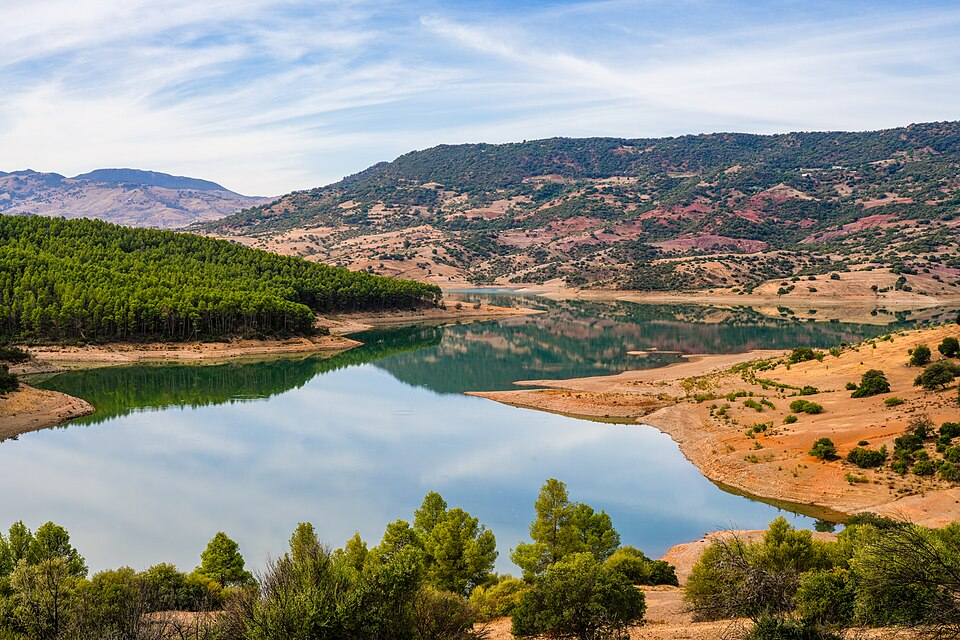

In [9]:
potd = result["picture_of_the_day"]
if potd.get("saved_image"):
    image_path = Path(potd["saved_image"])
    text_path = Path(potd["saved_description"])
    print(image_path.name)
    print(text_path.name)
    print()
    print(text_path.read_text(encoding="utf-8"))
    if image_path.suffix.lower() in (".jpg", ".jpeg", ".png"):
        display(Image(filename=str(image_path), width=420))
else:
    print("Картинка дня не сохранена, подробности в errors.json")

---
## Граф связей

Узел — статья, ребро — гиперссылка. Взаимные ссылки рисуются одним ребром `dir=both`.

In [10]:
dot = (OUTPUT / "graph.dot").read_text(encoding="utf-8")
print("строк в файле:", len(dot.splitlines()))
print("рёбер:", dot.count("->"), "| из них взаимных:", dot.count("dir=both"))
print()
print("\n".join(dot.splitlines()[:20]))

строк в файле: 170
рёбер: 125 | из них взаимных: 19

// Граф статей Википедии: Амурский тигр
digraph wikimedia {
	overlap=false rankdir=LR
	node [fontname=Arial fontsize=10 shape=box]
	Doi
	"Panthera tigris tigris"
	"Wayback Machine"
	"Алматинская область"
	"Амур (река)"
	"Амурский тигр" [fillcolor="#bfdcff" penwidth=2 style=filled]
	"Анюй (приток Амура)"
	"Балхашский район"
	"Бастак (заповедник)"
	"Большая советская энциклопедия"
	"Буффало"
	"Всемирный фонд дикой природы"
	"Геральдика"
	"Герб Приморского края"
	"Герб Хабаровского края"
	"Дальневосточное отделение Российской академии наук"


Самые связанные статьи — на них ведёт больше всего ссылок внутри выборки:

In [11]:
incoming = {article["title"]: 0 for article in result["articles"]}
for article in result["articles"]:
    for target in article["links"]:
        incoming[target] = incoming.get(target, 0) + 1

for title, count in sorted(incoming.items(), key=lambda pair: -pair[1])[:10]:
    print(f"{count:3}  {title}")

 14  Wayback Machine
 14  Национальная библиотека Чешской Республики
 11  Китай
 10  Приморский край
  7  Амурский тигр
  7  Большая советская энциклопедия
  5  Латвийская национальная библиотека
  4  Doi
  4  Герб Приморского края
  4  Еврейская автономная область


Граф картинкой (нужен установленный Graphviz):

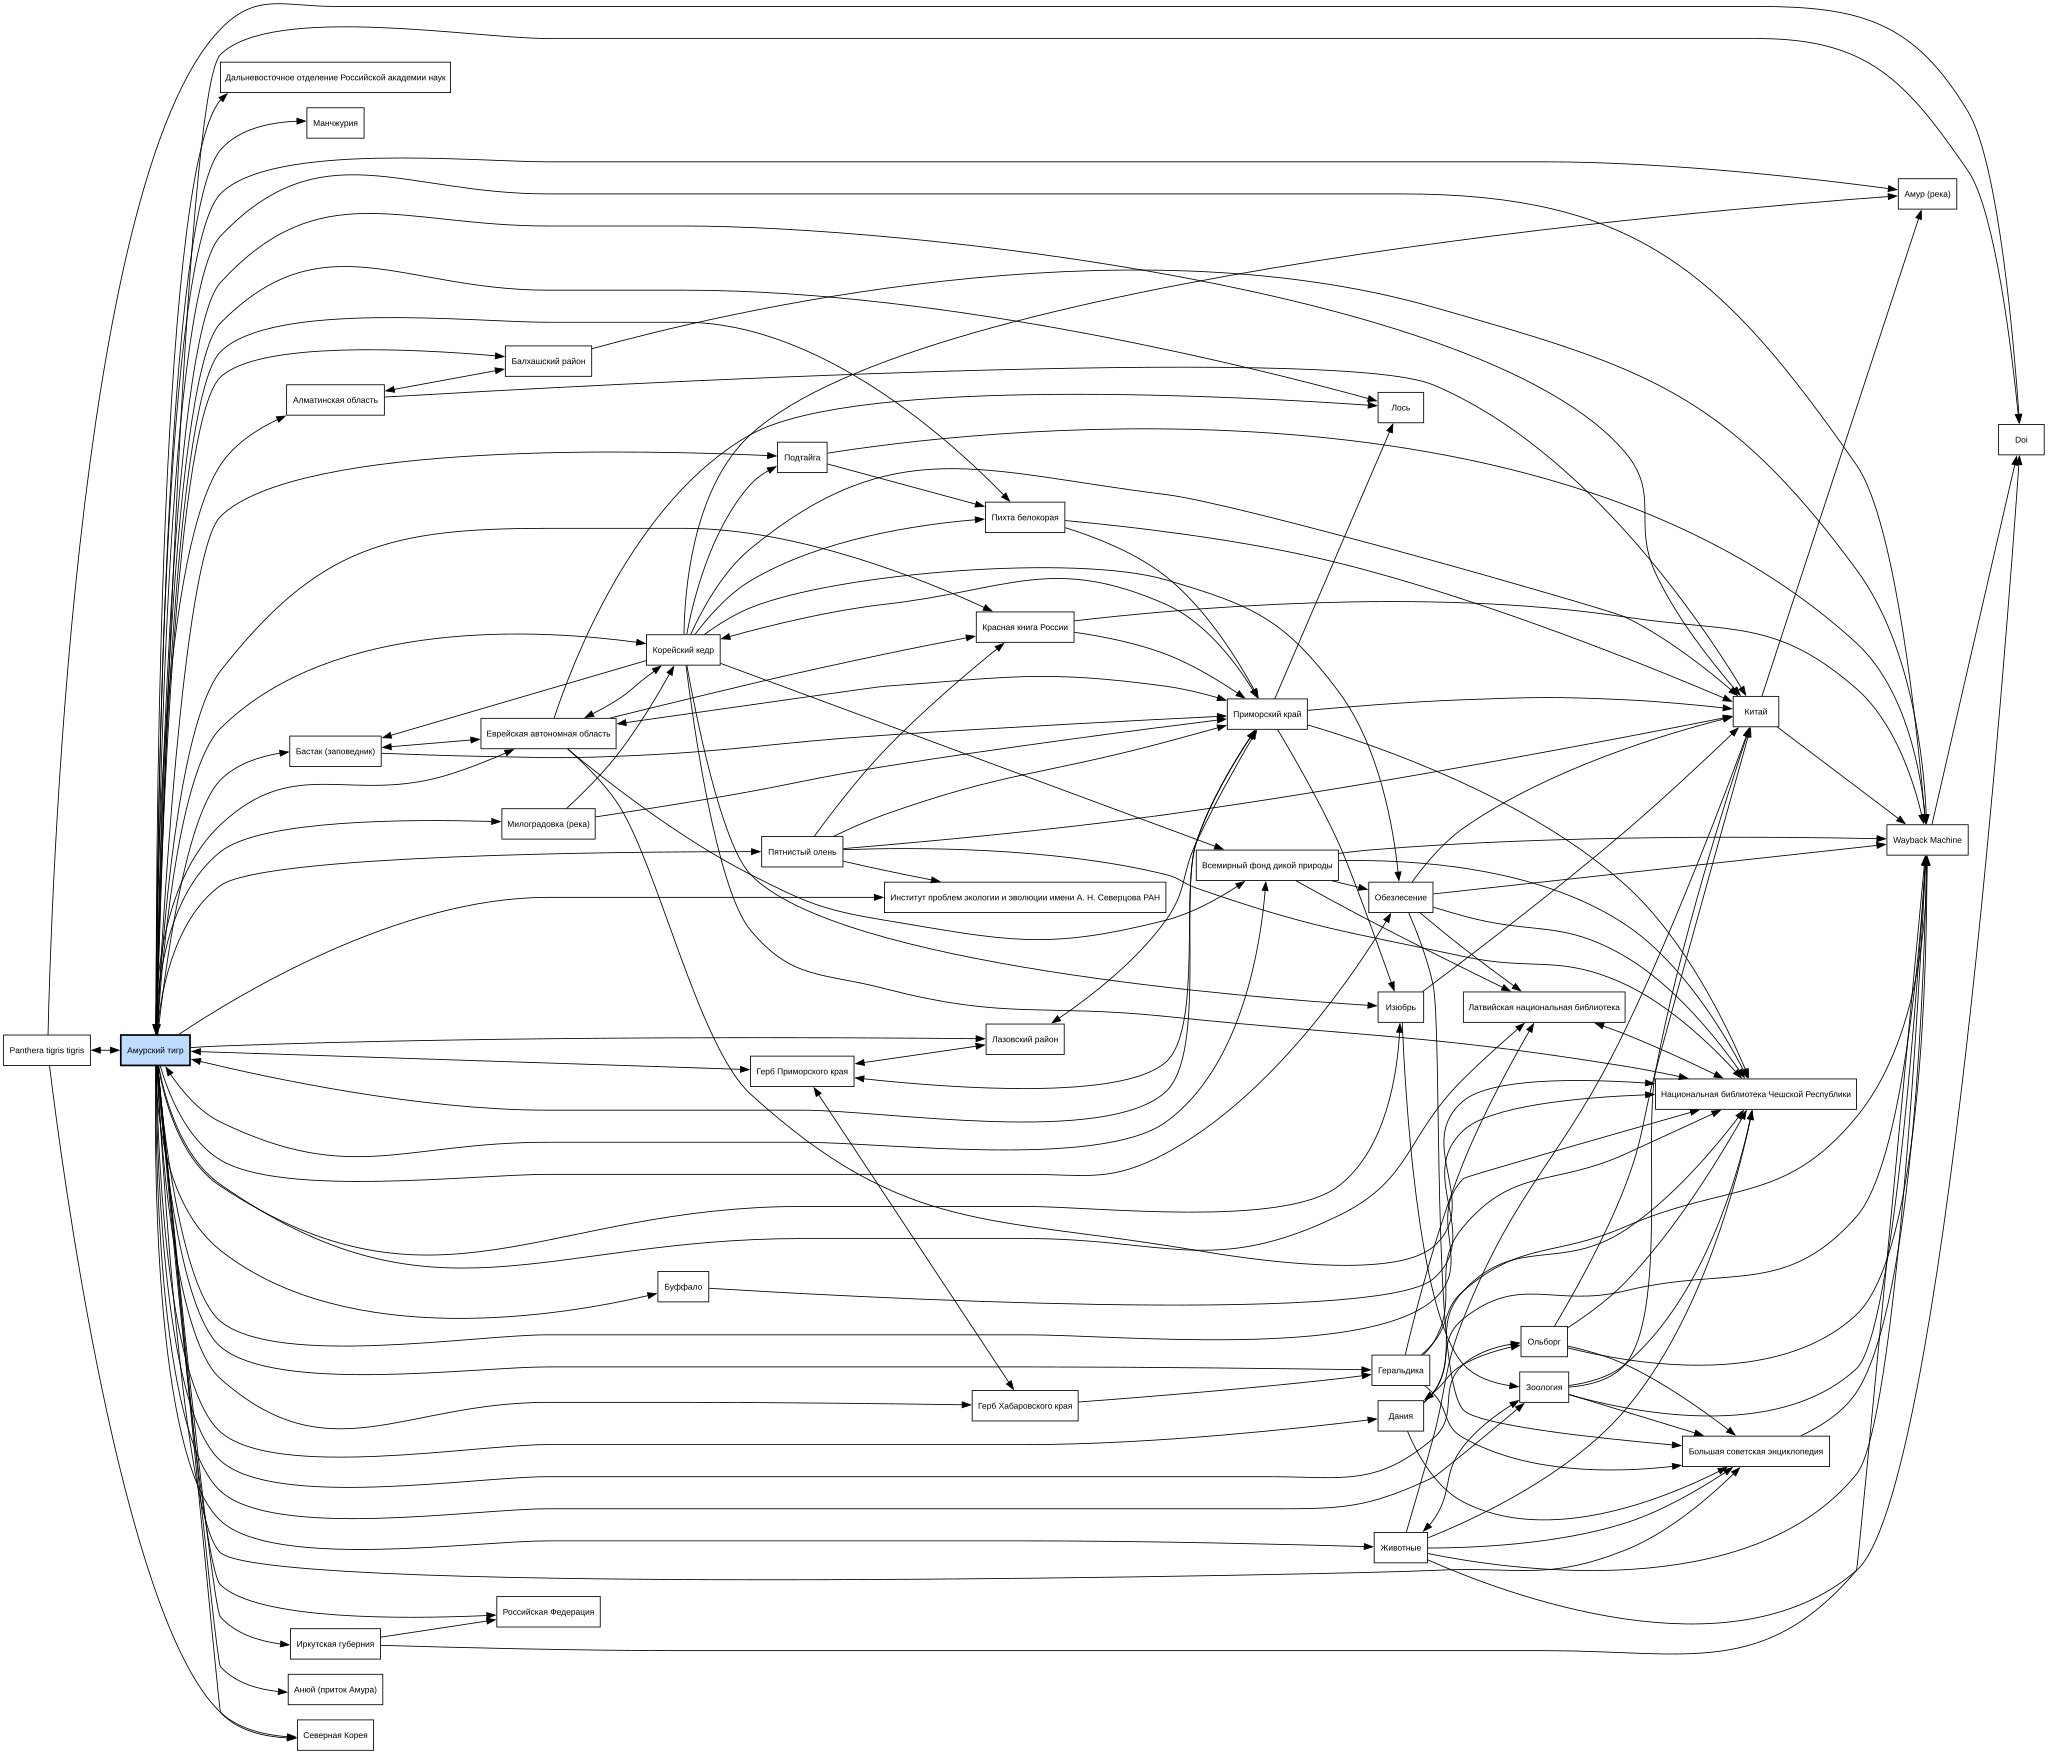

In [12]:
from IPython.display import SVG

picture = OUTPUT / "graph.dot.svg"
if picture.exists():
    display(SVG(filename=str(picture)))
else:
    print("Картинки нет — не установлена программа dot, см. README.")

### Неудачные запросы

In [13]:
errors = json.loads((OUTPUT / "errors.json").read_text(encoding="utf-8"))
print("ошибок:", len(errors))
for error in errors[:5]:
    print(f'{error["stage"]:12} {error["error"]}')

ошибок: 1
potd-image   HTTPError: 403


---
# Выводы

**Про API.** Все данные получены через документированные методы, без разбора HTML:
`action=query` даёт тексты, ссылки и изображения статей сразу пачками по 20 заголовков,
`wbgetentities` — сущность Викиданных, `generator=search` — файлы Commons. Единственное
место, где понадобился разбор HTML, — описания изображений: Commons отдаёт их с разметкой.

**Про граф.** Ребро здесь — гиперссылка, а она направлена по своей природе, поэтому граф
направленный: из статьи о животном есть ссылка на ареал обитания, обратной может не быть.
Взаимные ссылки не дублируются, а рисуются одним ребром со стрелкой в обе стороны —
по их доле видно, насколько плотно связана предметная область.

**Что пришлось отфильтровать.** Около половины гиперссылок Википедии — служебные:
категории, шаблоны, даты, списки. Они связывают статьи формально и превращают граф
в клубок, поэтому в выборку не попадают. Статьи берутся равномерно по всему списку
ссылок: API отдаёт их по алфавиту, и выборка подряд дала бы только первые буквы.

**Про ограничения API.** Wikimedia режет частые анонимные обращения, поэтому запросы идут
с паузой, с `User-Agent` по политике проекта и с повтором при `403`/`429`.
Что не прошло — видно в `errors.json`, а не теряется молча.